# A/B Test Analysis — RAG Chunk Size 256 vs 512
**System:** Mistral 7B (Ollama) + ChromaDB mlops_rag + all-MiniLM-L6-v2

This notebook runs the full A/B test simulation and displays statistical results.
See `docs/experiment-specification.md` for the full design and `docs/recommendation-memo.md` for the decision.

In [1]:
import sys
sys.path.insert(0, '..')
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load results from simulation
with open('../ab_test_results.json') as f:
    results = json.load(f)

print("=" * 55)
print("A/B Test Results: chunk_size=256 (A) vs chunk_size=512 (B)")
print("=" * 55)
for metric, r in results.items():
    sig = "SIGNIFICANT" if r['significant_at_bonferroni'] else "not significant"
    print(f"\n{metric.upper()}")
    print(f"  Variant A mean: {r['mean_a']}")
    print(f"  Variant B mean: {r['mean_b']}")
    print(f"  Difference (B-A): {r['diff_b_minus_a']:+.4f}")
    print(f"  p-value: {r['p_value']} ({sig})")
    print(f"  95% Bootstrap CI: {r['ci_95']}")

A/B Test Results: chunk_size=256 (A) vs chunk_size=512 (B)

GROUNDEDNESS
  Variant A mean: 0.6729
  Variant B mean: 0.7252
  Difference (B-A): +0.0524
  p-value: 0.0006 (SIGNIFICANT)
  95% Bootstrap CI: [0.0222, 0.0815]

LATENCY_S
  Variant A mean: 3.172
  Variant B mean: 3.3121
  Difference (B-A): +0.1401
  p-value: 0.1922 (not significant)
  95% Bootstrap CI: [-0.0753, 0.354]


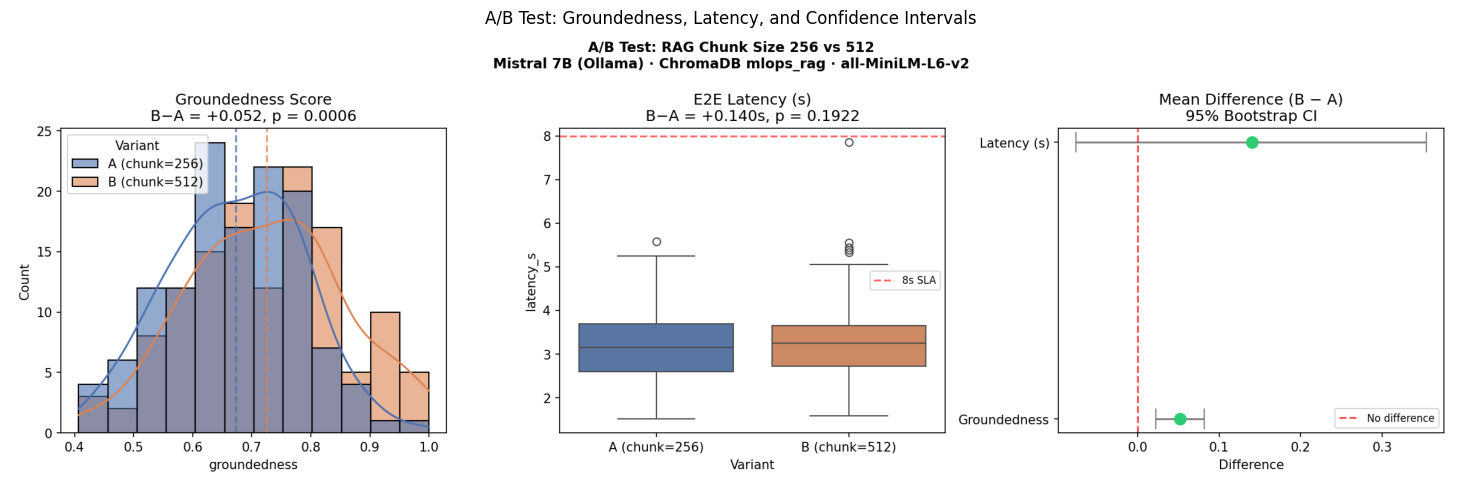

In [2]:
# Display A/B test visualization
img = mpimg.imread('../visualizations/ab_test_chunk_size.png')
plt.figure(figsize=(16, 5))
plt.imshow(img)
plt.axis('off')
plt.title('A/B Test: Groundedness, Latency, and Confidence Intervals', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusion

- **Groundedness:** Variant B (chunk_size=512) improved by +0.052 (p=0.0006) ✅ significant at Bonferroni-adjusted α=0.025
- **Latency:** +0.14s increase, p=0.19 ❌ not significant — no SLA impact
- **Decision:** Ship Variant B. See `docs/recommendation-memo.md` for full reasoning.